# Notebook 1: ResNet50 Model for RAF-DB Emotion Recognition


In [77]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import pandas as pd
import numpy as np
from PIL import Image
import os
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

In [78]:
# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [79]:
# Constants for RAF-DB (7 emotions)
EMOTIONS = ['Surprise', 'Fear', 'Disgust', 'Happy', 'Sad', 'Anger', 'Neutral']
NUM_CLASSES = len(EMOTIONS)
BATCH_SIZE = 32
EPOCHS = 20
LEARNING_RATE = 1e-4
IMG_SIZE = 224

In [80]:
# Early stopping class
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
        
    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

In [81]:
from torch.utils.data import Dataset
from pathlib import Path
from PIL import Image

class RAFDBDataset(Dataset):
    def __init__(self, root_dir, split='train', transform=None):

        self.root_dir = Path(root_dir) / split
        self.transform = transform
        self.images = []
        self.labels = []

        # RAF-DB has 7 emotion classes (1 → 7)
        for label in range(1, 8):

            class_folder = self.root_dir / str(label)

            if not class_folder.exists():
                print(f"Missing folder: {class_folder}")
                continue

            # Load ALL aligned images
            img_files = list(class_folder.glob('*_aligned.jpg'))

            for img_path in img_files:
                self.images.append(img_path)
                self.labels.append(label - 1)  # make 0–6

        print(f"Loaded {len(self.images)} images for {split} split")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        img_path = self.images[idx]
        label = self.labels[idx]

        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, label

In [82]:
# Data transforms
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [83]:
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [84]:
# Load datasets
data_dir = "/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET" 

In [85]:
print("Loading RAF-DB datasets...")
train_dataset = RAFDBDataset(data_dir, split='train', transform=train_transform)
test_dataset = RAFDBDataset(data_dir, split='test', transform=test_transform)

Loading RAF-DB datasets...
Loaded 12271 images for train split
Loaded 3068 images for test split


In [86]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, drop_last=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, drop_last=False)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Training samples: 12271
Test samples: 3068


In [87]:
# Initialize ResNet50 model
print("\nInitializing ResNet50 model...")
resnet50 = models.resnet50(pretrained=True)
num_features = resnet50.fc.in_features
resnet50.fc = nn.Linear(num_features, NUM_CLASSES)
resnet50 = resnet50.to(device)


Initializing ResNet50 model...


In [88]:
# Training function with early stopping
def train_resnet50(model, model_name, train_loader, test_loader, epochs=EPOCHS, patience=5):
    print(f"\n{'='*50}")
    print(f"Training {model_name} on RAF-DB with Early Stopping (patience={patience})")
    print('='*50)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)
    
    # Initialize early stopping
    early_stopping = EarlyStopping(patience=patience, min_delta=0.001)
    
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    best_val_acc = 0.0
    stopped_epoch = epochs
    
    for epoch in range(epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        train_pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs} [Train]')
        for inputs, labels in train_pbar:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            train_pbar.set_postfix({'loss': running_loss/(len(train_pbar)), 
                                   'acc': 100.*correct/total})
        
        train_loss = running_loss / len(train_loader)
        train_acc = 100. * correct / total
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        all_preds = []
        all_labels = []
        
        with torch.no_grad():
            val_pbar = tqdm(test_loader, desc=f'Epoch {epoch+1}/{epochs} [Val]')
            for inputs, labels in val_pbar:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item()
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()
                
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                
                val_pbar.set_postfix({'loss': val_loss/(len(val_pbar)), 
                                     'acc': 100.*correct/total})
        
        val_loss = val_loss / len(test_loader)
        val_acc = 100. * correct / total
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        
        scheduler.step(val_loss)
        
        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), f'best_{model_name}_rafdb.pth')
            print(f"✓ New best model saved with accuracy: {val_acc:.2f}%")
        
        print(f'Epoch {epoch+1}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')
        
        # Check early stopping
        early_stopping(val_loss)
        if early_stopping.early_stop:
            print(f"\n⚠️ Early stopping triggered at epoch {epoch+1}")
            stopped_epoch = epoch + 1
            break
    
    # Final evaluation with best model
    print(f"\n📊 Loading best model for final evaluation...")
    model.load_state_dict(torch.load(f'best_{model_name}_rafdb.pth'))
    model.eval()
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    return {
        'model_name': model_name,
        'train_losses': train_losses,
        'train_accs': train_accs,
        'val_losses': val_losses,
        'val_accs': val_accs,
        'best_val_acc': best_val_acc,
        'predictions': all_preds,
        'true_labels': all_labels,
        'stopped_epoch': stopped_epoch
    }

In [89]:
# Train ResNet50 on RAF-DB
print("\n" + "="*60)
print("STARTING RESNET50 TRAINING ON RAF-DB")
print("="*60)

resnet50_results = train_resnet50(resnet50, 'ResNet50_RAFDB', train_loader, test_loader, patience=5)


STARTING RESNET50 TRAINING ON RAF-DB

Training ResNet50_RAFDB on RAF-DB with Early Stopping (patience=5)


Epoch 1/20 [Val]: 100%|██████████| 96/96 [00:30<00:00,  3.14it/s, loss=0.599, acc=78.4] 


✓ New best model saved with accuracy: 78.36%
Epoch 1: Train Loss: 0.8955, Train Acc: 67.74% | Val Loss: 0.5994, Val Acc: 78.36%


Epoch 2/20 [Val]: 100%|██████████| 96/96 [00:10<00:00,  9.09it/s, loss=0.537, acc=82]   


✓ New best model saved with accuracy: 81.98%
Epoch 2: Train Loss: 0.5963, Train Acc: 78.75% | Val Loss: 0.5375, Val Acc: 81.98%


...

Epoch 11: Train Loss: 0.1578, Train Acc: 94.43% | Val Loss: 0.5888, Val Acc: 84.16%
EarlyStopping counter: 3 out of 5


Epoch 12/20 [Val]: 100%|██████████| 96/96 [00:10<00:00,  9.04it/s, loss=0.595, acc=84.8] 


Epoch 12: Train Loss: 0.1412, Train Acc: 94.93% | Val Loss: 0.5954, Val Acc: 84.78%
EarlyStopping counter: 4 out of 5


Epoch 13/20 [Val]: 100%|██████████| 96/96 [00:10<00:00,  9.03it/s, loss=0.531, acc=85.5] 


✓ New best model saved with accuracy: 85.53%
Epoch 13: Train Loss: 0.0657, Train Acc: 97.82% | Val Loss: 0.5312, Val Acc: 85.53%
EarlyStopping counter: 5 out of 5

⚠️ Early stopping triggered at epoch 13

📊 Loading best model for final evaluation...


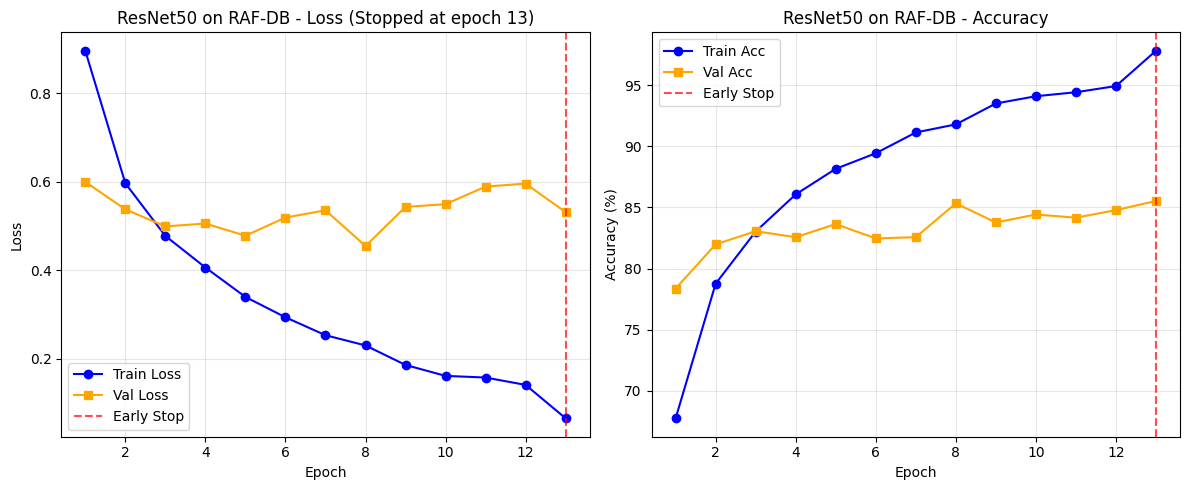

In [90]:
# Plotting results for ResNet50
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

epochs_range = range(1, len(resnet50_results['train_losses']) + 1)

# Plot losses
axes[0].plot(epochs_range, resnet50_results['train_losses'], label='Train Loss', marker='o', color='blue')
axes[0].plot(epochs_range, resnet50_results['val_losses'], label='Val Loss', marker='s', color='orange')
axes[0].axvline(x=resnet50_results['stopped_epoch'], color='red', linestyle='--', alpha=0.7, label='Early Stop')
axes[0].set_title(f'ResNet50 on RAF-DB - Loss (Stopped at epoch {resnet50_results["stopped_epoch"]})')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot accuracies
axes[1].plot(epochs_range, resnet50_results['train_accs'], label='Train Acc', marker='o', color='blue')
axes[1].plot(epochs_range, resnet50_results['val_accs'], label='Val Acc', marker='s', color='orange')
axes[1].axvline(x=resnet50_results['stopped_epoch'], color='red', linestyle='--', alpha=0.7, label='Early Stop')
axes[1].set_title('ResNet50 on RAF-DB - Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('resnet50_rafdb_training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

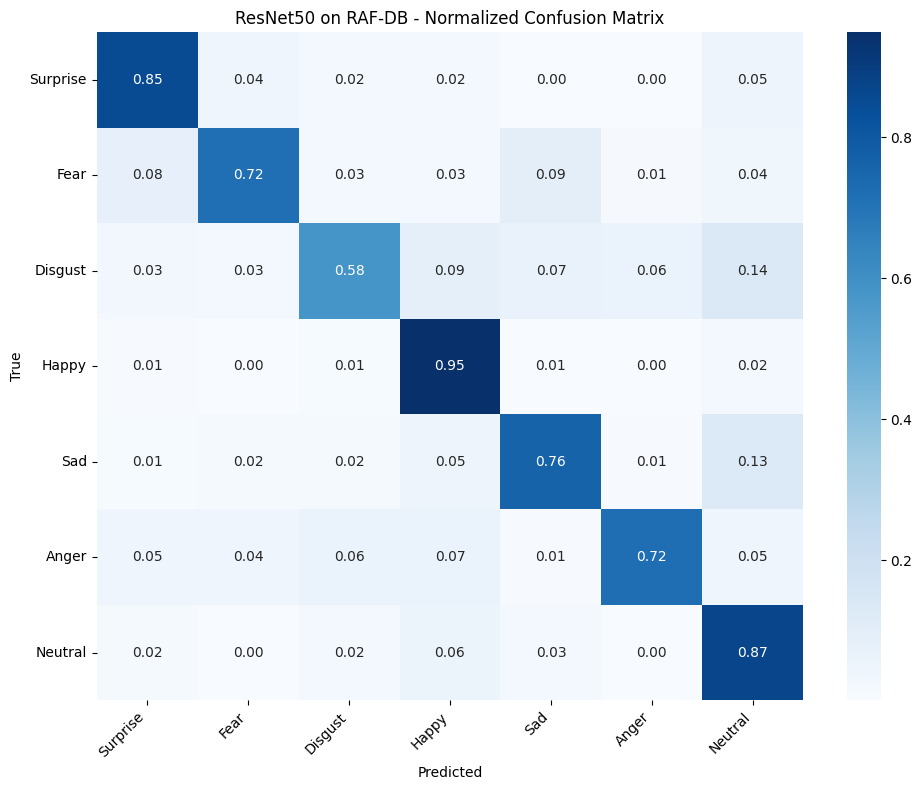

In [91]:
# Confusion matrix for ResNet50
plt.figure(figsize=(10, 8))
cm = confusion_matrix(resnet50_results['true_labels'], resnet50_results['predictions'])

# Normalize confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Plot
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues', 
            xticklabels=EMOTIONS, yticklabels=EMOTIONS)
plt.title('ResNet50 on RAF-DB - Normalized Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('resnet50_rafdb_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()


In [92]:
# Classification report for ResNet50
print("\n" + "="*60)
print("RESNET50 ON RAF-DB - CLASSIFICATION REPORT")
print("="*60)
print(classification_report(resnet50_results['true_labels'], resnet50_results['predictions'], 
                           target_names=EMOTIONS, zero_division=0, digits=4))

# Per-class performance analysis
print(f"\n📈 Detailed Analysis for ResNet50 on RAF-DB:")
cm = confusion_matrix(resnet50_results['true_labels'], resnet50_results['predictions'])

# Calculate per-class accuracy
class_acc = cm.diagonal() / cm.sum(axis=1)
print(f"\n{'Emotion':<15} {'Accuracy':<15}")
print("-"*30)
for emotion, acc in zip(EMOTIONS, class_acc):
    print(f"{emotion:<15} {acc*100:.2f}%")

# Find easiest and hardest emotions
best_class_idx = np.argmax(class_acc)
worst_class_idx = np.argmin(class_acc)
print(f"\n✅ Best performing emotion: {EMOTIONS[best_class_idx]} ({class_acc[best_class_idx]*100:.2f}%)")
print(f"❌ Worst performing emotion: {EMOTIONS[worst_class_idx]} ({class_acc[worst_class_idx]*100:.2f}%)")

# Save results
print(f"\n📁 ResNet50 on RAF-DB results saved")
print(f"   Best validation accuracy: {resnet50_results['best_val_acc']:.2f}%")
print(f"   Stopped at epoch: {resnet50_results['stopped_epoch']}")
print(f"   Total epochs trained: {len(resnet50_results['train_accs'])}")


RESNET50 ON RAF-DB - CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Surprise     0.8615    0.8511    0.8563       329
        Fear     0.5761    0.7162    0.6386        74
     Disgust     0.6159    0.5813    0.5981       160
       Happy     0.9191    0.9485    0.9336      1185
         Sad     0.8943    0.7615    0.8226       478
       Anger     0.8603    0.7222    0.7852       162
     Neutral     0.8079    0.8721    0.8388       680

    accuracy                         0.8553      3068
   macro avg     0.7907    0.7790    0.7819      3068
weighted avg     0.8572    0.8553    0.8545      3068


📈 Detailed Analysis for ResNet50 on RAF-DB:

Emotion         Accuracy       
------------------------------
Surprise        85.11%
Fear            71.62%
Disgust         58.13%
Happy           94.85%
Sad             76.15%
Anger           72.22%
Neutral         87.21%

✅ Best performing emotion: Happy (94.85%)
❌ Worst performing emotion: Disgust (58.13%)

